## AI Lab 15 Scikitlearn

### Task 1: Linear Regression
-  Use a small dataset (students’ study hours vs marks) to predict marks.
-  Evaluate MSE and plot regression line.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Mean Squared Error:  8.163265306122472


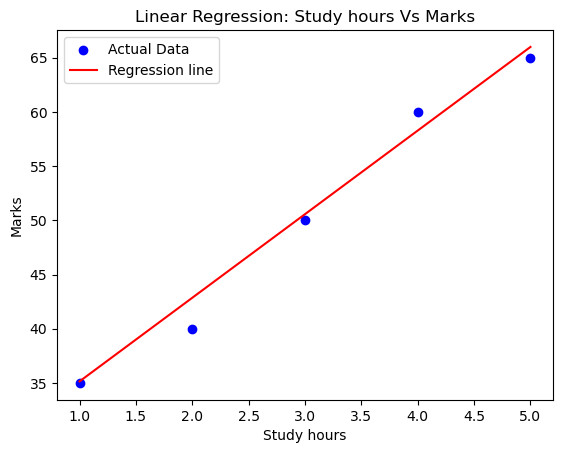

In [24]:
# study hours : input
x = np.array([1, 2, 3, 4, 5]).reshape(-1,1)

# Marks : output/target
y = np.array([35, 40, 50, 60, 65])

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

# Make Predictions
y_pred = model.predict(x_test)

# Mean Squared Error
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error: ", mse)

# Plotting the regression line
plt.scatter(x, y, color = "blue", label = "Actual Data")
plt.plot(x, model.predict(x), color ="red", label="Regression line")

plt.xlabel("Study hours")
plt.ylabel("Marks")
plt.title("Linear Regression: Study hours Vs Marks")
plt.legend()
plt.show()

### Task 2: Logistic Regression
- Use Iris dataset to predict species (binary and multi-class).
- Compute confusion matrix and accuracy.

In [14]:
# Binary classification
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
y = iris.target

# Converting to binary problem
# As to keep class 0 and class 1
X_binary = X[y != 2]
y_binary = y[y != 2]

# Train and Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_binary, y_binary, test_size = 0.2, random_state=42
)

# Train Logistic Regression Model 
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict classes
y_pred = model.predict(X_test)

# Confusion Matrix
from sklearn.metrics import confusion_matrix, accuracy_score 
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[12  0]
 [ 0  8]]
Accuracy: 1.0


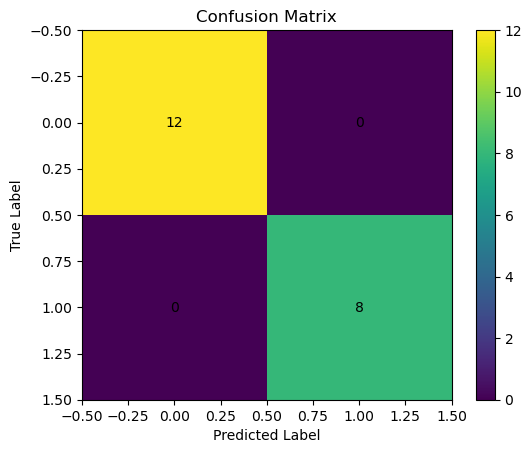

In [20]:
# Visualization of Confusion Matrix
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Show values inside the matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [26]:
# Multiclass classification
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[12  0]
 [ 0  8]]
Accuracy: 1.0


### Task 3: Decision Tree
- Train a Decision Tree classifier on Iris or Titanic dataset.
- Visualize the tree.

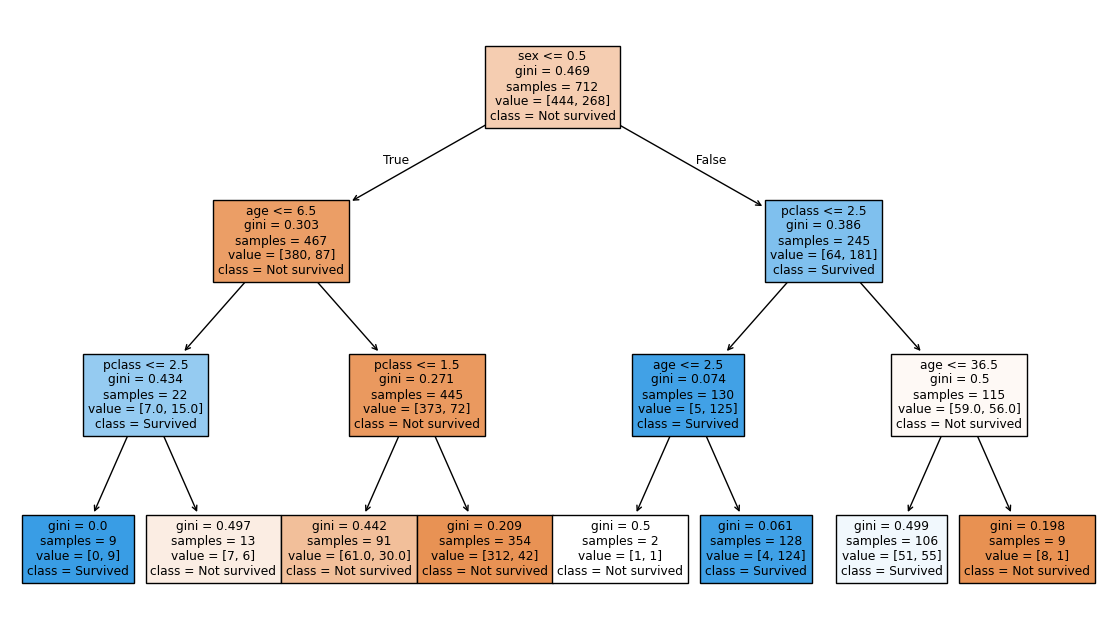

In [18]:
# We are using the Titanic Dataset
import seaborn as sns
import pandas as pd

titanic = sns.load_dataset("titanic")
# Selecting only the useful columns 
data = titanic[["sex", "age", "pclass", "survived"]].copy()
# Handling the missing data
data.loc[:,"age"] = data["age"].fillna(data["age"].median())

# Converting the categorical data to numbers
data.loc[:, "sex"] = data["sex"] = data["sex"].map({"male":0, "female":1}) 

# separate features and target
x = data[["sex", "age", "pclass"]] # Features 
y = data["survived"] # target

# Train and test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.2, random_state=42
)

# Train decision tree classifier
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=3)
model.fit(x_train, y_train)

# Visualize the Decision Tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))
plot_tree(
    model,
    feature_names=["sex", "age", "pclass"],
    class_names=["Not survived", "Survived"],
    filled = True
)
plt.show()


### Task 4: K-Means
- Generate synthetic 2D data and apply K-Means.
- Plot clusters and centroids.

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


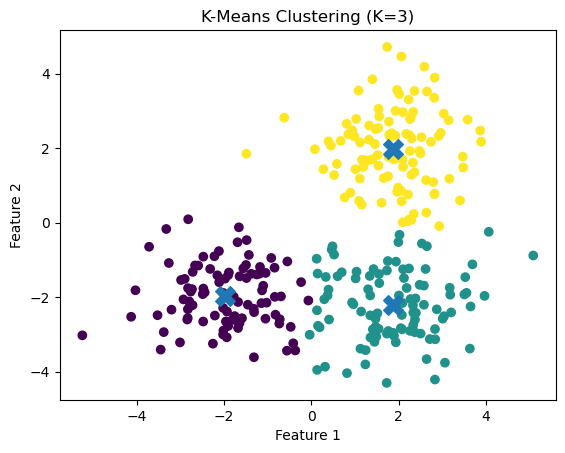

In [23]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Creating 2D data points
x = np.vstack([
    np.random.randn(100,2) + [2, 2],
    np.random.randn(100,2) + [-2, -2],
    np.random.randn(100,2) + [2,-2]
])
# Applying K-means algo
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(x)

# Get cluster labels and centroids
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Visualization - plot clusters and centroids
plt.scatter(x[:,0], x[:,1], c=labels)
plt.scatter(
    centroids[:,0],
    centroids[:,1],
    marker="X",
    s=200
)
plt.title("K-Means Clustering (K=3)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### Task 5: Support Vector Machine
- Train SVM on Iris dataset.
- Experiment with different kernels (linear, rbf).

In [3]:
from sklearn.datasets import load_iris

iris = load_iris()
x = iris.data
y = iris.target

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Train SVM with linear kernel
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_linear = SVC(kernel="linear")
svm_linear.fit(x_train, y_train)

y_pred_linear = svm_linear.predict(x_test)
acc_linear = accuracy_score(y_test, y_pred_linear)

print("Linear Kernel Accuracy: ", acc_linear)

Linear Kernel Accuracy:  1.0


In [5]:
# Train SVM with RBF kernel
svm_rbf = SVC(kernel="rbf")
svm_rbf.fit(x_train, y_train)

y_pred_rbf = svm_rbf.predict(x_test)
acc_rbf = accuracy_score(y_test, y_pred_rbf)

print("RBF Kernel Accuracy:", acc_rbf)

RBF Kernel Accuracy: 1.0


### Task 6: Random Forest
- Use Random Forest for classification on small dataset.
- Compare accuracy with Decision Tree.

In [10]:
import seaborn as sns
import pandas as pd

titanic = sns.load_dataset("titanic")

data = titanic[['sex', 'age', 'pclass', 'survived']].copy()

data.loc[:, "age"] = data["age"].fillna(data["age"].median())
data.loc[:, "sex"] = data["sex"].map({"male": 0, "female": 1})

x = data[['sex', 'age', 'pclass']]
y = data['survived']

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(x_train, y_train)

y_pred_dt = dt.predict(x_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", acc_dt)

# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,      # number of trees
    max_depth=3,           # keep trees comparable
    random_state=42
)

# 
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", acc_rf)



Decision Tree Accuracy: 0.8044692737430168
Random Forest Accuracy: 0.7932960893854749


### Task 7: Preprocessing
- Handle missing values in a dataset.
- Apply standard scaling on features.
- Train a simple model before and after scaling.

In [13]:
# Dataset Student names, attendence and marks
import pandas as pd
import numpy as np

data = pd.DataFrame({
    "Student": ["Ali", "Sara", "Ahmed", "Ayesha", "Usman"],
    "StudyHours": [2, 4, 3, 5, np.nan],
    "Attendance": [60, 75, np.nan, 90, 70],
    "Marks": [40, 55, 50, 65, 48]
})



In [17]:
# Handle Missing Values
# Replace the missing values with mean (simple and common)

data["StudyHours"] = data["StudyHours"].fillna(data["StudyHours"].mean())
data["Attendance"] = data["Attendance"].fillna(data["Attendance"].mean())

# Separate features and target
x = data[["StudyHours", "Attendance"]]
y = data["Marks"]

# Training a model before scaling

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
mse_before = mean_squared_error(y_test, y_pred)

print("MSE before scaling:", mse_before)

# Apply scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

x_train_s, x_test_s, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

# Model training after scaling

model_scaled = LinearRegression()
model_scaled.fit(x_train_s, y_train)

y_pred_scaled = model_scaled.predict(x_test_s)
mse_after = mean_squared_error(y_test, y_pred_scaled)

print("MSE after scaling:", mse_after)





MSE before scaling: 5.742549070138015
MSE after scaling: 5.7425490701380495
